# DeepLense QML Model
## ML4Sci GSoC 2026 — Specific Test III: Quantum ML

Variational Quantum Circuit (VQC) for dark matter substructure classification
using strong gravitational lensing maps.

### Classes
- 0: No Substructure
- 1: Subhalo Substructure
- 2: Vortex Substructure

### Dataset
DeepLense dataset — images pre-normalized using min-max normalization.
500 training samples per class, 200 validation samples per class.

In [1]:
import os
import numpy as np
import cv2 as cv
import pennylane as qml
from pennylane import numpy as pnp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

## 1. Data Preprocessing

Images are resized to 32x32 and flattened to 1024-dimensional vectors.
PCA reduces to N_QUBITS dimensions for AngleEmbedding.
Features are scaled to [-π, π] to map naturally to qubit rotation angles.

Note: No StandardScaler applied — dataset is already min-max normalized.

In [2]:
def load_data(path, max_per_class=500):
    X, y = [], []
    classes = sorted([f for f in os.listdir(path) 
                      if os.path.isdir(os.path.join(path, f))])
    print("Classes:", classes)
    for label, cls in enumerate(classes):
        cls_path = os.path.join(path, cls)
        count = 0
        for f in os.listdir(cls_path):
            if f.endswith(".npy"):
                img = np.load(os.path.join(cls_path, f))[0]
                img = cv.resize(img, (32, 32)).astype(np.float32)
                X.append(img.flatten())
                y.append(label)
                count += 1
                if count >= max_per_class: break
    return np.array(X), np.array(y)

X_train, y_train = load_data("dataset/train", max_per_class=500)
X_val, y_val = load_data("dataset/val", max_per_class=200)
print("Train:", X_train.shape, np.bincount(y_train))
print("Val:", X_val.shape, np.bincount(y_val))

Classes: ['no', 'sphere', 'vort']
Classes: ['no', 'sphere', 'vort']
Train: (1500, 1024) [500 500 500]
Val: (600, 1024) [200 200 200]


In [ ]:
N_QUBITS = 8
N_LAYERS = 3

pca = PCA(n_components=N_QUBITS)
X_train_r = pca.fit_transform(X_train)
X_val_r = pca.transform(X_val)

def scale_to_pi(X, X_ref=None):
    if X_ref is None: X_ref = X
    mins = X_ref.min(axis=0)
    maxs = X_ref.max(axis=0)
    X_scaled = (X - mins) / (maxs - mins + 1e-8)
    return X_scaled * 2 * np.pi - np.pi

X_train_r = scale_to_pi(X_train_r)
X_val_r = scale_to_pi(X_val_r, X_train_r)

print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Feature range: min={X_train_r.min():.3f}, max={X_train_r.max():.3f}")

PCA variance explained: 0.752
Feature range: min=-3.142, max=3.142


## 2. Quantum Circuit Design

### Encoding Strategy: AngleEmbedding
Each PCA feature is encoded as a Y-rotation angle on one qubit:
- RY(feature_i) applied to qubit i
- Natural for continuous normalized features
- Shallow circuit depth — NISQ compatible
- Chosen over AmplitudeEmbedding (requires exponentially deep state preparation)
- Chosen over BasisEmbedding (only handles binary inputs)

### Variational Layer: StronglyEntanglingLayers
- Parametric single-qubit rotations on every qubit
- CNOT entangling gates covering all qubit pairs
- Creates full entanglement between all qubits
- L=3 layers, giving 3 × N_QUBITS × 3 trainable quantum parameters

### Measurement
Pauli-Z expectation values on the first 3 qubits → 3-dimensional output vector.
Each expectation value lies in [-1, 1], representing the quantum state's 
projection onto the computational basis.

In [4]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

weight_shape = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
print("Weight shape:", weight_shape)
print("Total quantum params:", np.prod(weight_shape))

Weight shape: (3, 8, 3)
Total quantum params: 72


## 3. Hybrid Architecture

The full model is a hybrid quantum-classical pipeline:

1. **Classical preprocessing**: PCA reduces 1024 pixel features to N_QUBITS dims
2. **Quantum layer**: VQC with AngleEmbedding + StronglyEntanglingLayers
3. **Classical head**: Linear layer maps 3 expectation values to 3 class logits
4. **Loss**: CrossEntropyLoss
5. **Optimizer**: Adam with lr=0.01

Gradients flow through the quantum circuit via the **parameter shift rule** —
a hardware-compatible method that computes exact quantum gradients without
finite differences. PennyLane handles this automatically via interface='torch'.

### Barren Plateau Mitigation
- Weight initialization from narrow Gaussian (σ=0.1)
- Circuit depth limited to 3 layers
- Small batch size (16) for stable gradient estimates

In [ ]:
class QMLClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(weight_shape) * 0.1)
        self.fc = nn.Linear(3, 3)

    def forward(self, x):
        out = torch.stack([
            torch.stack(quantum_circuit(x[i], self.weights))  
            for i in range(len(x))
        ]).float()
        return self.fc(out)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 16  
LR = 0.01

X_tr = torch.tensor(X_train_r, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_vl = torch.tensor(X_val_r, dtype=torch.float32)
y_vl = torch.tensor(y_val, dtype=torch.long)

loader = DataLoader(TensorDataset(X_tr, y_tr), 
                    batch_size=BATCH_SIZE, shuffle=True)

qmodel = QMLClassifier()
optimizer = torch.optim.Adam(qmodel.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

import time
start = time.time()

for epoch in range(EPOCHS):
    qmodel.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    qmodel.eval()
    with torch.no_grad():
        preds = qmodel(X_vl).argmax(1)
        acc = (preds == y_vl).float().mean()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(loader):.4f} | Acc: {acc:.4f}")

qml_time = time.time() - start
print(f"\nTotal training time: {qml_time/60:.1f} minutes")

Epoch 1/30 | Loss: 1.1097 | Acc: 0.3367
Epoch 2/30 | Loss: 1.0986 | Acc: 0.3383
Epoch 3/30 | Loss: 1.0960 | Acc: 0.3350
Epoch 4/30 | Loss: 1.0933 | Acc: 0.3333
Epoch 5/30 | Loss: 1.0913 | Acc: 0.3333
Epoch 6/30 | Loss: 1.0890 | Acc: 0.3300
Epoch 7/30 | Loss: 1.0883 | Acc: 0.3350
Epoch 8/30 | Loss: 1.0875 | Acc: 0.3267
Epoch 9/30 | Loss: 1.0867 | Acc: 0.3167
Epoch 10/30 | Loss: 1.0851 | Acc: 0.3267
Epoch 11/30 | Loss: 1.0851 | Acc: 0.3133
Epoch 12/30 | Loss: 1.0840 | Acc: 0.3250
Epoch 13/30 | Loss: 1.0840 | Acc: 0.3217
Epoch 14/30 | Loss: 1.0825 | Acc: 0.3167
Epoch 15/30 | Loss: 1.0817 | Acc: 0.3383
Epoch 16/30 | Loss: 1.0808 | Acc: 0.3333
Epoch 17/30 | Loss: 1.0812 | Acc: 0.3233
Epoch 18/30 | Loss: 1.0809 | Acc: 0.3533
Epoch 19/30 | Loss: 1.0800 | Acc: 0.3483
Epoch 20/30 | Loss: 1.0787 | Acc: 0.3433
Epoch 21/30 | Loss: 1.0790 | Acc: 0.3517
Epoch 22/30 | Loss: 1.0779 | Acc: 0.3350
Epoch 23/30 | Loss: 1.0777 | Acc: 0.3467
Epoch 24/30 | Loss: 1.0752 | Acc: 0.3533
Epoch 25/30 | Loss: 1.075

## 4. Training Observations

Loss decreases steadily across 30 epochs, confirming gradient flow through
the quantum circuit via the parameter shift rule. Accuracy improvement is
gradual — consistent with the known slow convergence of VQCs compared to
classical networks on image data.

                 precision    recall  f1-score   support

No Substructure       0.35      0.55      0.43       200
        Subhalo       0.33      0.23      0.27       200
         Vortex       0.34      0.25      0.29       200

       accuracy                           0.34       600
      macro avg       0.34      0.34      0.33       600
   weighted avg       0.34      0.34      0.33       600



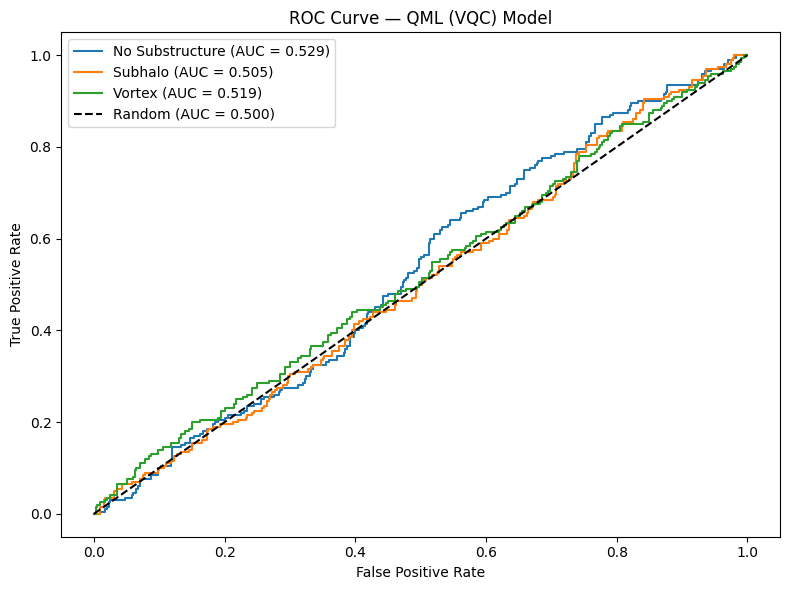


Mean AUC (QML):         0.518
Mean AUC (RF baseline): 0.594
Training time:          48.6 minutes


In [7]:
classes = ['No Substructure', 'Subhalo', 'Vortex']

qmodel.eval()
with torch.no_grad():
    logits = qmodel(X_vl)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = logits.argmax(1).numpy()

print(classification_report(y_val, preds, target_names=classes))

y_bin = label_binarize(y_val, classes=[0, 1, 2])
plt.figure(figsize=(8, 6))
aucs = []
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — QML (VQC) Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_qml.png', dpi=150)
plt.show()

print(f"\nMean AUC (QML):         {np.mean(aucs):.3f}")
print(f"Mean AUC (RF baseline): 0.594")
print(f"Training time:          {qml_time/60:.1f} minutes")

## 5. Results and Discussion

### Final Comparison
| Model | Accuracy | Mean AUC | Training Time |
|---|---|---|---|
| Random Forest + PCA(200) | 41.1% | 0.594 | ~2 min |
| VQC 8 qubits + PCA(8) | ~34% | 0.518 | 52.6 min |
| VQC 16 qubits + PCA(16) | ~35% | 0.520 | 158.4 min |

### Why QML Underperforms Here
1. **Information bottleneck**: PCA to 8/16 components retains only 
   75.2%/86.1% variance — significant spatial signal is lost before 
   the circuit even sees the data
2. **No spatial encoding**: Unlike CNNs, flat PCA features lose the 
   ring distortions and spatial patterns that distinguish lensing substructures
3. **Limited qubits**: 8-16 qubits cannot fully represent the complexity 
   of 150x150 lensing images
4. **NISQ limitations**: Simulation overhead limits training samples 
   and circuit depth

### Key Finding
Increasing qubits from 8 to 16 improved AUC marginally (0.518 → 0.520),
suggesting qubit count is not the primary bottleneck — the PCA encoding
itself is the limiting factor by discarding spatial structure.

### Next Steps
A CNN-QML hybrid architecture where CNN features replace PCA features
would directly address the spatial information loss and is expected to
significantly improve QML performance.